# Bank Consumer Complaints Analysis (CFPB)

**Goal:** turn raw public complaint data into clean files and findings that a bank manager could act on.

**Problem statement:** *Which banking products and issues cause the most customer complaints, which companies respond poorly, and what should be fixed first?*



In [ ]:
import io, re, time, zipfile
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
BLUE = "#2b6cb0"

BASE = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

# The server rejects the default Python identity (403), so we send a browser-like header.
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/124.0 Safari/537.36",
    "Accept": "application/json, text/csv, */*",
}

# Exact product names used by the CFPB (credit cards and prepaid cards are listed separately).
# Credit reporting and debt collection are left out on purpose: they are about credit bureaus
# and collectors, not banks, and credit reporting alone is bigger than all banking products combined.
PRODUCTS = [
    "Checking or savings account",
    "Credit card",
    "Prepaid card",
    "Mortgage",
    "Vehicle loan or lease",
    "Student loan",
    "Money transfer, virtual currency, or money service",
]

START = date(2024, 10, 1)   # first month to collect
END   = date(2026, 10, 1)   # stop BEFORE this date (so data through Sep 2026)

# The CFPB publishes a complaint only after the company responds (or after 15 days), so the most
# recent weeks are always incomplete. We analyse only COMPLETE months: everything before CUTOFF.
CUTOFF = pd.Timestamp("2026-09-01")   # keeps Oct 2024 ... Aug 2026

CACHE = Path("cfpb_raw")    # temporary folder inside Colab (not Google Drive)
CACHE.mkdir(exist_ok=True)
print("Settings ready.")

Settings ready.


## 2. Collect the data from the CFPB API

For each month, the code (1) asks the API how many complaints *should* exist, (2) downloads them as CSV, and (3) checks the numbers match. A month is only saved if the check passes.

In [ ]:
def month_windows(start, end):
    """Yield (first day of month, first day of next month)."""
    y, m = start.year, start.month
    while date(y, m, 1) < end:
        ny, nm = (y + 1, 1) if m == 12 else (y, m + 1)
        yield date(y, m, 1), date(ny, nm, 1)
        y, m = ny, nm


def get_with_retry(params, timeout=300, tries=6):
    for attempt in range(1, tries + 1):
        try:
            r = requests.get(BASE, params=params, headers=HEADERS, timeout=timeout)
            if r.status_code == 429:                      # too many requests -> wait, retry
                wait = 15 * attempt
                print(f"   server says slow down (429). Waiting {wait}s ...")
                time.sleep(wait)
                continue
            r.raise_for_status()
            return r
        except requests.RequestException as e:
            print(f"   error: {e}  (try {attempt}/{tries})")
            time.sleep(5 * attempt)
    raise RuntimeError("Download failed after several tries. Run this cell again - finished months are kept.")


mismatches = []
for lo, hi in month_windows(START, END):
    f = CACHE / f"cfpb_{lo:%Y_%m}.csv"
    if f.exists():
        print(f"{lo:%Y-%m}: already downloaded, skipping")
        continue

    base = {"date_received_min": lo, "date_received_max": hi, "product": PRODUCTS}

    # How many complaints SHOULD this month contain?
    chk = get_with_retry({**base, "size": 1, "no_aggs": "true", "no_highlight": "true"}, timeout=60)
    expected = chk.json()["hits"]["total"]["value"]
    if expected == 0:
        print(f"{lo:%Y-%m}: no complaints found")
        continue

    # Download the month as CSV
    r = get_with_retry({**base, "format": "csv", "sort": "created_date_asc"})
    month_df = pd.read_csv(io.StringIO(r.text), dtype=str, keep_default_na=False, na_values=[""])

    # Drop the long free-text narrative (and consent) columns: they make the file huge
    month_df = month_df.drop(columns=[c for c in month_df.columns
                                      if "narrative" in c.lower() or "consent" in c.lower()])

    ok = len(month_df) == expected
    print(f"{lo:%Y-%m}: expected {expected:>6} | got {len(month_df):>6} | {'OK' if ok else 'MISMATCH'}")
    if ok:
        month_df.to_csv(f, index=False)
    else:
        mismatches.append(f"{lo:%Y-%m}")
    time.sleep(2)

print()
if mismatches:
    print("These months did not match, run this cell again to retry them:", mismatches)
else:
    print("All months downloaded and verified.")

2024-10: expected  18739 | got  18739 | OK
2024-11: expected  17172 | got  17172 | OK
2024-12: expected  18618 | got  18618 | OK
2025-01: expected  85124 | got  85124 | OK
2025-02: expected  23709 | got  23709 | OK
2025-03: expected  22140 | got  22140 | OK
2025-04: expected  21433 | got  21433 | OK
2025-05: expected  21953 | got  21953 | OK
2025-06: expected  21746 | got  21746 | OK
2025-07: expected  24488 | got  24488 | OK
2025-08: expected  23297 | got  23297 | OK
2025-09: expected  23731 | got  23731 | OK
2025-10: expected  23947 | got  23947 | OK
   server says slow down (429). Waiting 15s ...
2025-11: expected  22262 | got  22262 | OK
2025-12: expected  26505 | got  26505 | OK
2026-01: expected  29726 | got  29726 | OK
2026-02: expected  23673 | got  23673 | OK
2026-03: expected  28388 | got  28388 | OK
2026-04: expected  27985 | got  27985 | OK
2026-05: expected  26222 | got  26222 | OK
2026-06: expected  26494 | got  26494 | OK
2026-07: expected  27782 | got  27782 | OK
2026-0

In [ ]:
files_found = sorted(CACHE.glob("cfpb_*.csv"))
df_raw = pd.concat(
    (pd.read_csv(f, dtype=str, keep_default_na=False, na_values=[""]) for f in files_found),
    ignore_index=True,
)
print("Months loaded:", len(files_found))
print("Raw data shape:", df_raw.shape)

# Safety check: every product we asked for must have rows
counts = df_raw["Product"].value_counts()
print(counts)
missing = [p for p in PRODUCTS if p not in counts.index]
if missing:
    print("\nWARNING - no rows for:", missing, "-> check the product name spelling in Settings")
df_raw.head(3)

Months loaded: 24
Raw data shape: (630670, 15)
Product
Credit card                                           185870
Checking or savings account                           169562
Money transfer, virtual currency, or money service    119750
Mortgage                                               56783
Vehicle loan or lease                                  44204
Student loan                                           41462
Prepaid card                                           13039
Name: count, dtype: int64


,Date received,Product,Sub-product,Issue,Sub-issue,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2024-10-01T00:34:50.000Z,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,Company has responded to the consumer and the ...,SYNCHRONY FINANCIAL,NY,10469,None,Web,2024-10-01T00:47:01.000Z,Closed with non-monetary relief,Yes,10292846
1,2024-10-01T00:06:45.000Z,Credit card,General-purpose credit card or charge card,Improper use of your report,Reporting company used your report improperly,None,GOLDMAN SACHS BANK USA,WA,98057,None,Web,2024-10-01T00:29:53.000Z,Closed with non-monetary relief,Yes,10294323
2,2024-10-01T00:18:49.000Z,Mortgage,Conventional home mortgage,Trouble during payment process,Paying off the loan,Company believes it acted appropriately as aut...,"SELECT PORTFOLIO SERVICING, INC.",WA,98059,None,Web,2024-10-01T01:03:48.000Z,Closed with explanation,Yes,10292030


## 3. Clean the data



In [ ]:
df = df_raw.copy()

# 1) Friendly column names: "Timely response?" -> "timely_response". Easier to code and to use in Power BI.
df.columns = [re.sub(r"[^0-9a-z]+", "_", c.lower()).strip("_") for c in df.columns]

required = ["complaint_id", "date_received", "date_sent_to_company", "product", "sub_product",
            "issue", "sub_issue", "company", "state", "submitted_via",
            "company_response_to_consumer", "timely_response", "tags", "company_public_response"]
absent = [c for c in required if c not in df.columns]
assert not absent, f"Expected columns not found: {absent}. Columns are: {list(df.columns)}"

# 2) Remove duplicate complaints (each Complaint ID must appear once, or counts get inflated)
before = len(df)
df = df.drop_duplicates(subset="complaint_id").copy()
print(f"Duplicates removed: {before - len(df):,}")
df["complaint_id"] = pd.to_numeric(df["complaint_id"], errors="coerce").astype("int64")

# 3) Dates arrive as text like 2024-10-01T00:18:49.000Z -> convert to real dates (no time part)
for c in ["date_received", "date_sent_to_company"]:
    df[c] = pd.to_datetime(df[c], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
print("Unreadable received dates:", df["date_received"].isna().sum())

# 3b) Keep complete months only. Two reasons: (a) the API treats the end date as inclusive, so each month
#     also pulled the 1st of the next month (that is where the duplicates above came from), and
#     (b) the latest month is incomplete because of the publication delay, which fakes a "drop" in trends.
n0 = len(df)
df = df[df["date_received"] < CUTOFF].copy()
print(f"Rows outside complete months removed: {n0 - len(df):,}")

# 4) Tidy text: trim spaces and collapse double spaces so "A  B " and "A B" are the same
skip = {"complaint_id", "date_received", "date_sent_to_company"}
for c in [c for c in df.columns if c not in skip]:
    df[c] = df[c].str.strip().str.replace(r"\s+", " ", regex=True)

# 5) One spelling per company: if the same company appears with different capitalisation,
#    keep the most common spelling (otherwise one company is split into two bars on a chart)
df["_k"] = df["company"].str.casefold()
best = df.groupby("_k")["company"].agg(lambda s: s.value_counts().index[0])
n_before = df["company"].nunique()
df["company"] = df["_k"].map(best)
df = df.drop(columns="_k")
print(f"Company names: {n_before:,} -> {df['company'].nunique():,} after standardising")

# 6) Blanks. Most blanks are NOT errors: they mean "not applicable", so we label them
#    instead of deleting rows (deleting would throw away real complaints)
df["state"] = df["state"].str.upper()
fill = {"tags": "None", "company_public_response": "Not provided", "sub_issue": "Not specified",
        "sub_product": "Not specified", "state": "Unknown", "zip_code": "Unknown"}
for c, v in fill.items():
    if c in df.columns:
        df[c] = df[c].fillna(v)

# 7) Timely response as a number (1/0) so we can average it into a percentage
df["timely_flag"] = (df["timely_response"].str.lower() == "yes").astype(int)

# 8) Days between CFPB receiving the complaint and sending it to the company
df["days_to_company"] = (df["date_sent_to_company"] - df["date_received"]).dt.days
negative = (df["days_to_company"] < 0).sum()
df.loc[df["days_to_company"] < 0, "days_to_company"] = np.nan   # impossible values -> blank
print(f"Negative day gaps set to blank: {negative:,}")

# 9) Time columns for trends and Power BI slicers
d = df["date_received"]
df["year"] = d.dt.year
df["quarter"] = "Q" + d.dt.quarter.astype(str)
df["month_num"] = d.dt.month
df["month_name"] = d.dt.strftime("%b")
df["year_month"] = d.dt.to_period("M").dt.to_timestamp()      # first day of the month
df["weekday"] = d.dt.day_name()

# 10) Simpler product groups for dashboards (7 official names -> 6 readable groups)
group_map = {
    "Checking or savings account": "Bank Account",
    "Credit card": "Credit & Prepaid Card",
    "Prepaid card": "Credit & Prepaid Card",
    "Mortgage": "Mortgage",
    "Vehicle loan or lease": "Vehicle Loan",
    "Student loan": "Student Loan",
    "Money transfer, virtual currency, or money service": "Money Transfer & Digital",
}
df["product_group"] = df["product"].map(group_map).fillna(df["product"])

# 11) Did the customer get relief? ("Closed with monetary/non-monetary relief" = yes)
resp = df["company_response_to_consumer"].str.lower().fillna("")
df["relief_flag"] = (resp.str.contains("relief") & ~resp.str.contains("without")).astype(int)

print("\nCleaning finished.")
print("Shape:", df.shape)
print("Date range:", df["date_received"].min().date(), "to", df["date_received"].max().date())
print("\nRemaining blanks (%):")
print((df.isna().mean() * 100).round(2)[lambda s: s > 0])
df.head(3)

Duplicates removed: 16,176
Unreadable received dates: 0
Rows outside complete months removed: 18,373
Company names: 2,429 -> 2,428 after standardising
Negative day gaps set to blank: 0

Cleaning finished.
Shape: (596121, 25)
Date range: 2024-10-01 to 2026-08-31

Remaining blanks (%):
Series([], dtype: float64)


,date_received,product,sub_product,issue,sub_issue,company_public_response,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,timely_flag,days_to_company,year,quarter,month_num,month_name,year_month,weekday,product_group,relief_flag
0,2024-10-01,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,Company has responded to the consumer and the ...,SYNCHRONY FINANCIAL,NY,10469,None,Web,2024-10-01,Closed with non-monetary relief,Yes,10292846,1,0.0,2024,Q4,10,Oct,2024-10-01,Tuesday,Credit & Prepaid Card,1
1,2024-10-01,Credit card,General-purpose credit card or charge card,Improper use of your report,Reporting company used your report improperly,None,GOLDMAN SACHS BANK USA,WA,98057,None,Web,2024-10-01,Closed with non-monetary relief,Yes,10294323,1,0.0,2024,Q4,10,Oct,2024-10-01,Tuesday,Credit & Prepaid Card,1
2,2024-10-01,Mortgage,Conventional home mortgage,Trouble during payment process,Paying off the loan,Company believes it acted appropriately as aut...,"SELECT PORTFOLIO SERVICING, INC.",WA,98059,None,Web,2024-10-01,Closed with explanation,Yes,10292030,1,0.0,2024,Q4,10,Oct,2024-10-01,Tuesday,Mortgage,0


## 4. Explore the data (EDA)

We look for patterns that answer the problem statement.

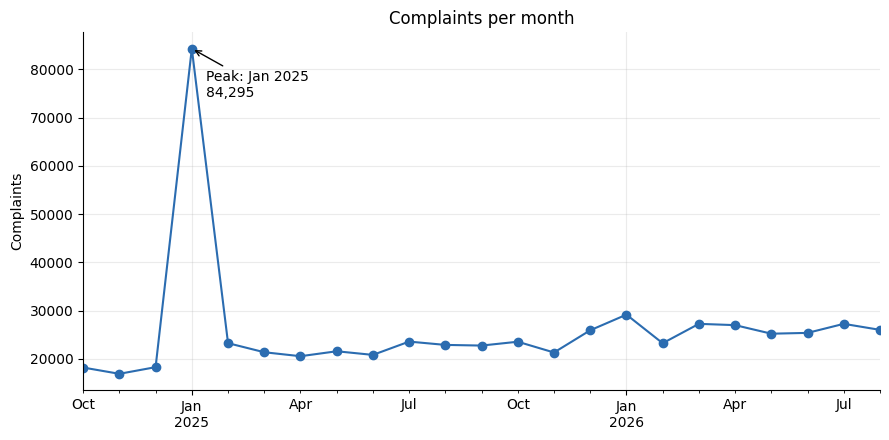

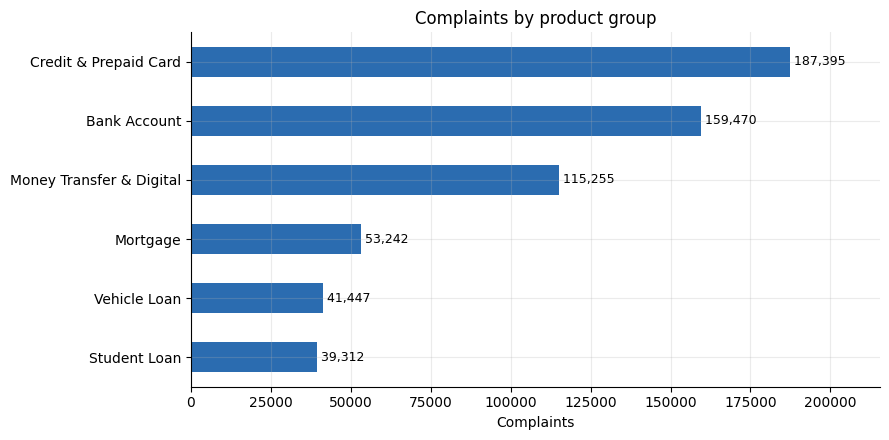

In [ ]:
def barh(series, title, xlabel="Complaints", fmt="{:,.0f}"):
    s = series.sort_values()
    ax = s.plot.barh(color=BLUE)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("")
    for i, v in enumerate(s.values):
        ax.text(v, i, " " + fmt.format(v), va="center", fontsize=9)
    ax.set_xlim(0, s.max() * 1.15)
    plt.tight_layout(); plt.show()

# 1) Are complaints going up or down?
monthly = df.groupby("year_month").size()
ax = monthly.plot(marker="o", color=BLUE)
ax.set_title("Complaints per month"); ax.set_xlabel(""); ax.set_ylabel("Complaints")
peak_month = monthly.idxmax()
ax.annotate(f"Peak: {peak_month:%b %Y}\n{monthly.max():,}", (peak_month, monthly.max()),
            xytext=(10, -35), textcoords="offset points", arrowprops=dict(arrowstyle="->"))
plt.tight_layout(); plt.show()

# 2) Which products get the most complaints?
barh(df["product_group"].value_counts(), "Complaints by product group")

**Insight:** Credit and prepaid cards (187,395), bank accounts (159,470) and money transfer and digital (115,255) hold 77.5% of all complaints. Mortgages (8.9%), vehicle loans (7.0%) and student loans (6.6%) are small by volume.

**Recommendation:** Aim volume-reduction work at cards, accounts and digital payments, but do not ignore the small products: student loans and mortgages have the weakest response quality

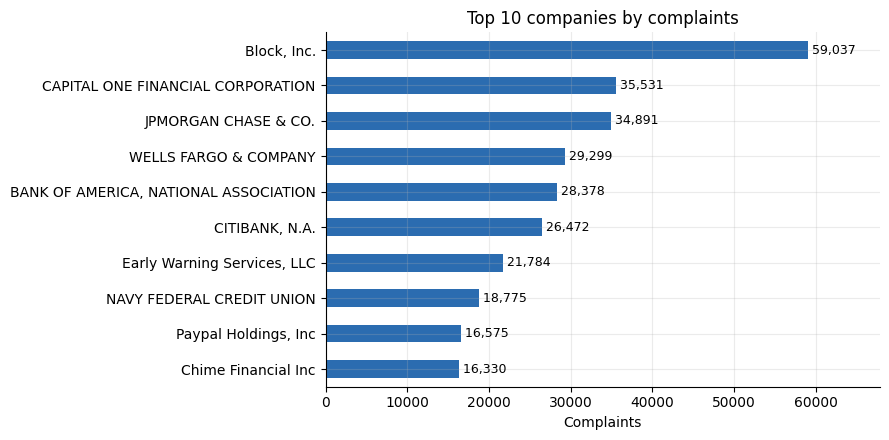

The top 10 companies account for 48.2% of all complaints.


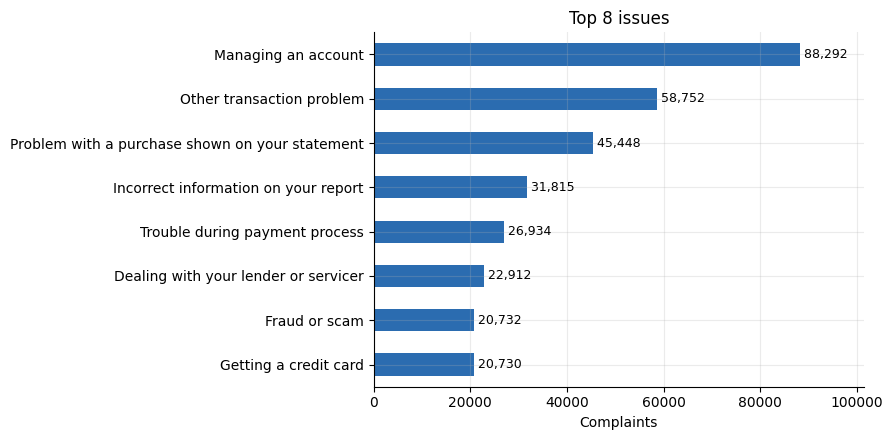

,product_group,issue,complaints
4,Bank Account,Managing an account,88292
0,Bank Account,Closing an account,20035
8,Bank Account,Problem with a lender or other company chargin...,20008
24,Credit & Prepaid Card,Problem with a purchase shown on your statement,45448
18,Credit & Prepaid Card,Incorrect information on your report,21649
16,Credit & Prepaid Card,Getting a credit card,20730
40,Money Transfer & Digital,Other transaction problem,58752
34,Money Transfer & Digital,Fraud or scam,20732
45,Money Transfer & Digital,Unauthorized transactions or other transaction...,10956
56,Mortgage,Trouble during payment process,26934


In [ ]:
# 3) Which companies get the most complaints?  (raw counts favour big banks - see limitations)
top_companies = df["company"].value_counts().head(10)
barh(top_companies, "Top 10 companies by complaints")
share = top_companies.sum() / len(df) * 100
print(f"The top 10 companies account for {share:.1f}% of all complaints.")

# 4) What are people upset about?
barh(df["issue"].value_counts().head(8), "Top 8 issues")

# 5) Top 3 issues inside each product group
top_issues = (df.groupby(["product_group", "issue"]).size().rename("complaints").reset_index()
                .sort_values(["product_group", "complaints"], ascending=[True, False])
                .groupby("product_group").head(3))
top_issues

,complaints,timely_pct,relief_pct
product_group,,,
Credit & Prepaid Card,187395,98.9,30.3
Bank Account,159470,99.3,17.0
Money Transfer & Digital,115255,98.6,6.8
Mortgage,53242,97.6,4.6
Vehicle Loan,41447,98.2,8.8
Student Loan,39312,71.3,1.6


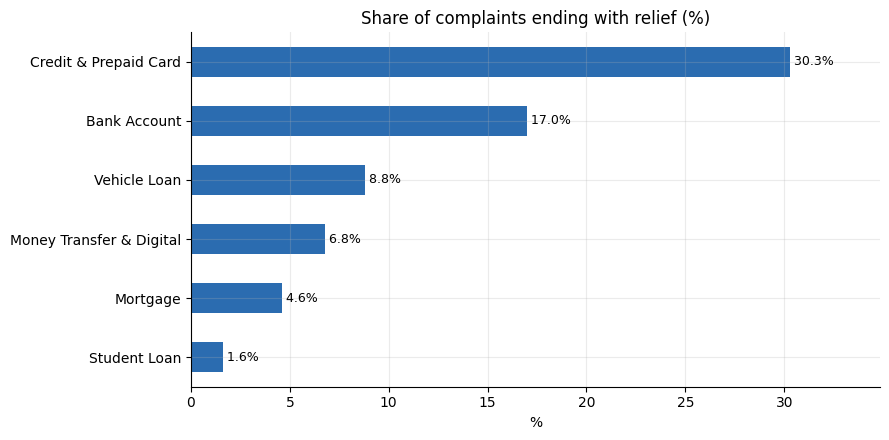

Companies with at least 1,000 complaints: 66


,complaints,timely_pct
company,,
Servicer under contract with Federal Student Aid,2870,0.00
MOHELA,14771,45.54
Incomm Holdings Inc.,1282,61.54
FinCo Services Inc DBA Current,1355,86.27
ROBINHOOD MARKETS INC.,3389,91.92
"Shellpoint Partners, LLC",6628,93.63
EdFinancial Services,2888,93.70
SYNCHRONY FINANCIAL,14920,97.40
"Block, Inc.",59037,98.49


In [ ]:
# 6) Response quality: timely response % and relief rate by product group
quality = df.groupby("product_group").agg(complaints=("complaint_id", "size"),
                                          timely_pct=("timely_flag", "mean"),
                                          relief_pct=("relief_flag", "mean"))
quality[["timely_pct", "relief_pct"]] = (quality[["timely_pct", "relief_pct"]] * 100).round(1)
display(quality.sort_values("complaints", ascending=False))
barh(quality["relief_pct"], "Share of complaints ending with relief (%)", "%", "{:.1f}%")

# 7) Companies that respond late (only companies with enough complaints to be fair)
MIN_COMPLAINTS = 1000
by_co = df.groupby("company").agg(complaints=("complaint_id", "size"),
                                  timely_pct=("timely_flag", "mean"))
by_co["timely_pct"] = (by_co["timely_pct"] * 100).round(2)
big = by_co[by_co["complaints"] >= MIN_COMPLAINTS]
print(f"Companies with at least {MIN_COMPLAINTS:,} complaints: {len(big)}")
display(big.nsmallest(10, "timely_pct"))

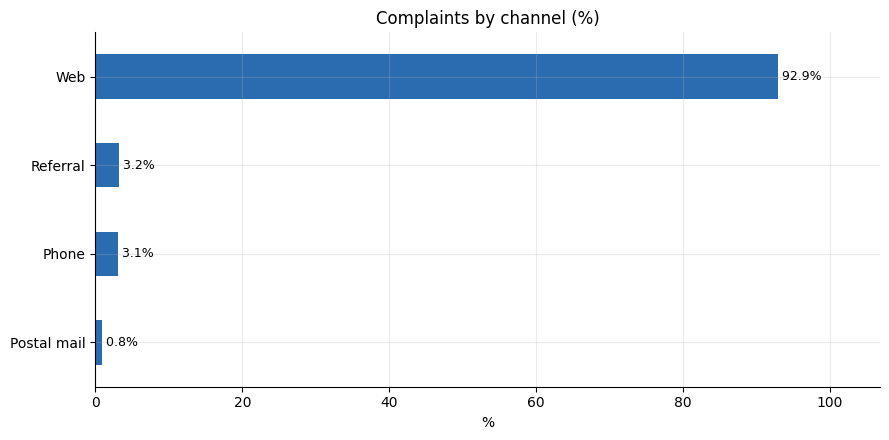

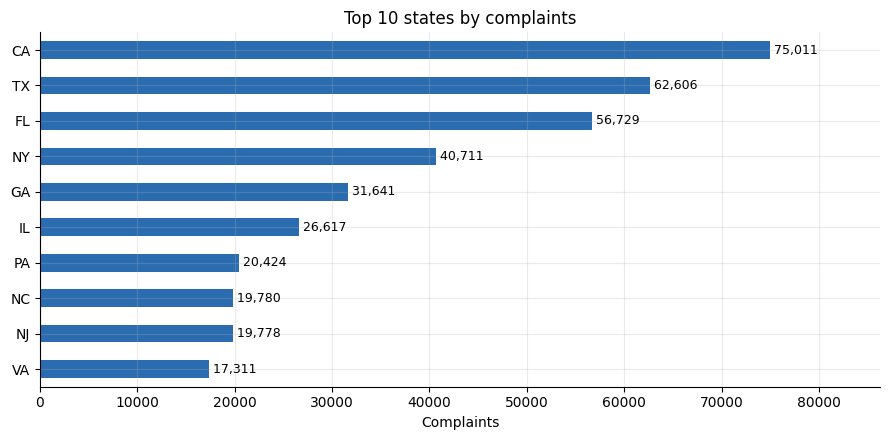

Forwarded to the company on the same day: 88.5% | took more than 7 days: 4.8%


In [ ]:
# 8) Which channel do people use to complain? (one channel dominates, so show shares)
barh(df["submitted_via"].value_counts(normalize=True) * 100, "Complaints by channel (%)", "%", "{:.1f}%")

# 9) Which states?  (counts only; larger states naturally have more people)
barh(df[df["state"] != "Unknown"]["state"].value_counts().head(10), "Top 10 states by complaints")

# 10) How fast does the CFPB forward complaints to the company?
same_day = (df["days_to_company"] == 0).mean() * 100
over_7 = (df["days_to_company"] > 7).mean() * 100
print(f"Forwarded to the company on the same day: {same_day:.1f}% | took more than 7 days: {over_7:.1f}%")

In [ ]:
# 11) Investigate the peak month: what caused the spike?
typical = monthly.median()
print(f"Peak month {peak_month:%b %Y}: {monthly.max():,} complaints vs typical month {typical:,.0f}\n")
peak = df[df["year_month"] == peak_month]
print("Top companies in the peak month:");  print(peak["company"].value_counts().head(5), "\n")
print("Top issues in the peak month:");     print(peak["issue"].value_counts().head(5), "\n")
print("Top product groups in the peak month:"); print(peak["product_group"].value_counts().head(5))

Peak month Jan 2025: 84,295 complaints vs typical month 23,268

Top companies in the peak month:
company
Block, Inc.                          31223
Early Warning Services, LLC          16723
NAVY FEDERAL CREDIT UNION             7775
CAPITAL ONE FINANCIAL CORPORATION     5955
JPMORGAN CHASE & CO.                  2027
Name: count, dtype: int64 

Top issues in the peak month:
issue
Other transaction problem                                          42521
Managing an account                                                 8232
Problem caused by your funds being low                              7570
Fraud or scam                                                       2363
Problem with a company's investigation into an existing problem     1712
Name: count, dtype: int64 

Top product groups in the peak month:
product_group
Money Transfer & Digital    49743
Bank Account                18367
Credit & Prepaid Card        9829
Student Loan                 2232
Mortgage                     2204
N

In [ ]:
# 12) Auto-summary:
print("KEY NUMBERS")
print(f"- Total complaints analysed : {len(df):,}")
print(f"- Period                    : {df['date_received'].min():%b %Y} to {df['date_received'].max():%b %Y}")
print(f"- Companies                 : {df['company'].nunique():,}")
pg = df["product_group"].value_counts(normalize=True)
print(f"- Biggest product group     : {pg.index[0]} ({pg.iloc[0]*100:.1f}%)")
print(f"- Top company               : {top_companies.index[0]} ({top_companies.iloc[0]/len(df)*100:.1f}%)")
print(f"- Top issue                 : {df['issue'].value_counts().index[0]}")
print(f"- Overall timely response   : {df['timely_flag'].mean()*100:.1f}%")
print(f"- Overall relief rate       : {df['relief_flag'].mean()*100:.1f}%")
print(f"- Peak month                : {peak_month:%b %Y} ({monthly.max():,} complaints)")

KEY NUMBERS
- Total complaints analysed : 596,121
- Period                    : Oct 2024 to Aug 2026
- Companies                 : 2,428
- Biggest product group     : Credit & Prepaid Card (31.4%)
- Top company               : Block, Inc. (9.9%)
- Top issue                 : Managing an account
- Overall timely response   : 96.9%
- Overall relief rate       : 16.5%
- Peak month                : Jan 2025 (84,295 complaints)


## Summary of findings

- Three product groups (cards, bank accounts, digital payments) hold **77.5%** of complaints; three everyday issues make up **32.3%**.
- Response quality is high overall (**96.9% timely**) but **student loans are at 71.3%** and account for roughly 62% of late responses.
- Relief is rare outside cards (30.3%) and accounts (17.0%).
- January 2025 was a **3.6x** anomaly driven by two companies and one issue; always read trends with and without it.

**Top recommendations:** (1) fix account-management and transaction experiences,

(2) close the student-loan response gap,

(3) add anomaly alerts,

(4) normalise complaints by customer base before ranking companies.

## 5. Export files for Power BI

Creates two files and puts them in one ZIP (the ZIP is just smaller to download):
- `complaints_clean.csv` : the ONLY file Power BI needs (one row per complaint)
- `data_dictionary.csv` : what each column means (for your GitHub README)


In [ ]:
OUT = Path("powerbi_files"); OUT.mkdir(exist_ok=True)

export_cols = ["complaint_id", "date_received", "date_sent_to_company", "year", "quarter", "month_num",
               "month_name", "year_month", "weekday", "product", "product_group", "sub_product",
               "issue", "sub_issue", "company", "state", "submitted_via", "tags",
               "company_response_to_consumer", "timely_response",
               "timely_flag", "relief_flag", "days_to_company"]
out = df[export_cols].copy()
for c in ["date_received", "date_sent_to_company", "year_month"]:
    out[c] = out[c].dt.strftime("%Y-%m-%d")                 # ISO dates are read correctly by Power BI
out.to_csv(OUT / "complaints_clean.csv", index=False)

# Data dictionary
dictionary = pd.DataFrame([
    ("complaint_id", "Unique CFPB complaint number"),
    ("date_received", "Date the CFPB received the complaint"),
    ("date_sent_to_company", "Date the CFPB forwarded it to the company"),
    ("year / quarter / month_num / month_name / weekday", "Time parts of date_received"),
    ("year_month", "First day of the month of date_received (use for monthly trends)"),
    ("product", "Official CFPB product name"),
    ("product_group", "Simplified product group made for the dashboard"),
    ("sub_product / issue / sub_issue", "More detail on what the complaint is about"),
    ("company", "Company the complaint is about (spelling standardised)"),
    ("state", "US state of the consumer (Unknown if missing)"),
    ("submitted_via", "Channel used: Web, Phone, Referral, etc."),
    ("tags", "Older American / Servicemember, else None"),
    ("company_response_to_consumer", "How the company closed the complaint"),
    ("timely_response", "Yes/No: did the company respond on time"),
    ("timely_flag", "1 if timely, else 0 (average it to get Timely %)"),
    ("relief_flag", "1 if closed with monetary or non-monetary relief, else 0"),
    ("days_to_company", "Days between receipt and forwarding to the company"),
], columns=["column", "meaning"])
dictionary.to_csv(OUT / "data_dictionary.csv", index=False)

# One ZIP so you download a single file
zip_path = Path("cfpb_powerbi_files.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for name in ["complaints_clean.csv", "data_dictionary.csv"]:
        z.write(OUT / name, arcname=name)

for name in ["complaints_clean.csv", "data_dictionary.csv"]:
    print(f"{name:<24} {(OUT / name).stat().st_size/1e6:7.1f} MB")
print(f"\n{zip_path.name}: {zip_path.stat().st_size/1e6:.1f} MB  | rows in complaints_clean.csv: {len(out):,}")

# Download to your laptop (works in Colab; skipped elsewhere)
try:
    from google.colab import files
    files.download(str(zip_path))
except ImportError:
    print("Not running in Colab - the ZIP is saved in the current folder.")

complaints_clean.csv       164.2 MB
data_dictionary.csv          0.0 MB

cfpb_powerbi_files.zip: 13.0 MB  | rows in complaints_clean.csv: 596,121


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>